# creating our own Batch Gradient class from scratch:

In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
X,y =load_diabetes(return_X_y=True)

In [4]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [5]:

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
reg =LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [11]:
#it will give us values of coefficients for each column value

In [8]:
print(reg.coef_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]


In [9]:
print(reg.intercept_)

151.88331005254167


In [10]:
y_pred =reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

# Creating our own class-

# we already have input and output columns, we simply have to find out values of y^. and this is how these values are refered to:


 # (y^ is used in inerementing the values)
 # `y^=Beta0 +X`






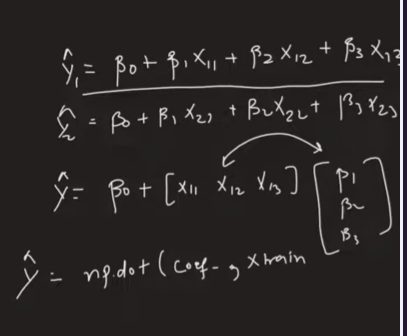

In [40]:
class GDRegressor:
  def __init__(self,learning_rate=0.01,epochs=100):
    self.coef_=None
    self.intercept_=None
    self.lr=learning_rate
    self.epochs=epochs

  def fit(self,X_train,y_train):
    #initialize your coefficients
    self.intercept_=0
    self.coef_=np.ones(X_train.shape[1])
     #this will tell the code that
    #how many coefficients are there.


    #updating values of intercepts:
    for i in range(self.epochs):
      y_hat= np.dot(X_train,self.coef_) + self.intercept_

      #print("shape of y^ is:",y_hat.shape)
      intercept_der = -2+ np.mean(y_train - y_hat)
      self.intercept_=self.intercept_-(self.lr*intercept_der)
      #updating values of coefficients:

      coef_der =-2 *np.dot((y_train-y_hat),X_train)/X_train.shape[0]
      self.coef_= self.coef_-(self.lr +coef_der)

    print(self.intercept_,self.coef_)

  def predict(self,X_test):
    return np.dot(X_test,self.coef_) + self.intercept_

In [50]:
gdr =GDRegressor(epochs =100,learning_rate=0.1)


In [52]:
gdr.fit(X_train, y_train)


-2042227.088855851 [   280.96592947 -52421.53419642 -74632.02985793  -8275.33888739
 -31341.97360502 -71457.64641896  84022.30915543 -97472.85483644
  -3030.1514179  -31490.92875128]


In [53]:
y_pred = gdr.predict(X_test)

In [54]:
r2_score(y_test, y_pred)

-757627132.961578